# Predicting New York House Prices: A Machine Learning Approach

**Author:** Baron Okoko  
**Institution:**   
**Course:** Final Year Project  
**Dataset:** NY-House-Dataset Price Prediction

## 1. Introduction

Property valuation has long been treated as a craft, something assessors and estate agents develop over years of local exposure. The problem with that approach is it does not scale, and it is difficult to audit. Two appraisers can walk through the same apartment and arrive at prices $200,000 apart, both confident they are right. Data-driven models do not eliminate disagreement, but they make the reasoning explicit and testable.

New York City presents a particularly useful case study. It is one of the most heterogeneous real estate markets in the world: a studio in the Bronx and a Manhattan townhouse can be separated by thirty minutes on the subway and a factor of fifty in price. That variance is not random; it follows patterns tied to geography, building type, size, and brokerage market structure. The question is whether a model can learn those patterns well enough to be useful.

This project builds a full supervised learning pipeline for NYC house price prediction, starting from a raw CSV with several data quality problems and ending with an ensembled gradient boosting model evaluated on a held-out test set. The objective is not just predictive accuracy but methodological rigour: leakage prevention, honest evaluation, and interpretable engineering decisions throughout.

### 1.1 Objectives

1. Clean and validate the raw dataset, documenting each removal decision.
2. Construct a leakage-free train/test split and confine all preprocessing to the training partition.
3. Engineer features that extract spatial and market-structure signals that raw columns cannot provide directly.
4. Compare a broad set of algorithms, from linear baselines to gradient boosting, under consistent cross-validation conditions.
5. Tune the best-performing models with Bayesian optimisation and combine them into a voting ensemble.
6. Evaluate the final model on the hold-out set and interpret where it works and where it fails.

### 1.2 Pipeline Overview

| Stage | Description |
|---|---|
| Data cleaning | Sentinel removal, corrupt value filtering, borough/ZIP parsing |
| Partitioning | Stratified 70/30 split on price quintiles before any fitting |
| Outlier removal | Isolation Forest on training set only |
| Feature engineering | RBF spatial encoding, leave-one-out frequency counts |
| Preprocessing | Yeo-Johnson, RobustScaler, OHE, OrdinalEncoder |
| Baseline comparison | 10 models, RepeatedKFold CV, MAPE scoring |
| Hyperparameter tuning | Optuna TPE, 50 trials per model |
| Ensembling | Equal-weight VotingRegressor |
| Evaluation | Hold-out MAPE, residual diagnostics, feature importance |

In [ ]:
!pip install skimpy -q
%load_ext cuml.accel

In [2]:
import re
import warnings
from dataclasses import dataclass, field

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from optuna.samplers import TPESampler
from skimpy import skim
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import RepeatedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    RobustScaler,
)
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Data

### 2.1 Source and Structure

The dataset is the NY House Dataset sourced from Kaggle. It contains 4,801 property listings scraped from a real estate aggregator, covering residential sales across New York City's five boroughs plus adjacent areas. Each row represents a single listed property with 17 columns spanning price, structural characteristics, geospatial coordinates, broker metadata, and administrative identifiers.

The column breakdown by type: 11 string (categorical and address text), 4 float64 (continuous measurements and coordinates), and 2 int64 (discrete counts). The dataset reports zero missing values, which sounds ideal until you look more closely; the "no missing values" claim is technically true but misleading, because missing data was imputed before release, leaving artifacts that need to be handled explicitly.

### 2.2 Data Quality Issues

Three structural problems are present in the raw data.

**Integer overflow in PRICE and PROPERTYSQFT.** The maximum price in the dataset is exactly 2,147,483,647; INT32_MAX, the largest value a 32-bit signed integer can hold. This is a SQL overflow artifact: the original price exceeded what the database column type could store, so it was silently capped. Similarly, PROPERTYSQFT has a maximum of 65,535; UINT16_MAX, the same artifact from a 16-bit unsigned integer column. Both values are impossible real estate figures and are dropped entirely rather than imputed.

**Corrupt bathroom values.** Exactly 302 rows share the identical bathroom count of 2.3738608579684373. The number of bathrooms cannot be an irrational looking float that repeats across hundreds of diverse properties. The most likely explanation is a failed join or a database default that overwrote valid values. These rows are dropped.

**Non-transactional listing types.** The dataset includes listings categorised as Pending, Contingent, Coming Soon, and Foreclosure. These are not completed sales and their prices reflect different market conditions; asking prices under contingency, distressed asset prices, and more. Including them alongside standard listings would add noise to the target variable, so they are excluded.

**The STATE column.** Despite its name, STATE contains city names, borough names, ZIP codes, and partial address strings concatenated together. This column is parsed into two cleaner features; borough and ZIP code; then dropped.

### 2.3 Summary Statistics

In [ ]:
df = pd.read_csv("mydata/NY-House-Dataset.csv")
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 4801   │ │ string      │ 11    │                                                          │
│ │ Number of columns │ 17     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column        ┃ NA  ┃ NA % ┃ mean    ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75     ┃ p100       ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ PRICE         │   0 │    0 │ 2357000 │ 31360000 │   2494 │ 499000 │ 825000 │ 1495000 │ 2147000000 │   █    │  │
│ │ BEDS          │   0 │    0 │   3.357 │    2.602 │      1 │      2 │      3 │       4 │         50 │   █    │  │
│ │ BATH          │   0 │    0 │   2.374 │    1.947 │      0 │      1 │      2 │       3 │         50 │   █    │  │
│ │ PROPERTYSQFT  │   0 │    0 │    2184 │     2377 │    230 │   1200 │   2184 │    2184 │      65540 │   █    │  │
│ │ LATITUDE      │   0 │    0 │   40.71 │  0.08768 │   40.5 │  40.64 │  40.73 │   40.77 │      40.91 │ ▁▅▄█▄▂ │  │
│ │ LONGITUDE     │   0 │    0 │  -73.94 │   0.1011 │ -74.25 │ -73.99 │ -73.95 │  -73.87 │      -73.7 │ ▁▂▄█▅▁ │  │
│ └───────────────┴─────┴──────┴─────────┴──────────┴────────┴────────┴────────┴─────────┴────────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ BROKERTIT │  0 │    0 │ NoBroker  │ Brokered  │ Brokered  │ NoBroker  │      34.3 │       5.6 │      26802 │  │
│ │ LE        │    │      │           │ by Steven │ by 1 Oak  │           │           │           │            │  │
│ │           │    │      │           │ Corcoran  │ Real      │           │           │           │            │  │
│ │           │    │      │           │ Real      │ Estate    │           │           │           │            │  │
│ │           │    │      │           │ Estate    │ Hub Inc   │           │           │           │            │  │
│ │           │    │      │           │ LLC -     │           │           │           │           │            │  │
│ │           │    │      │           │ Steven    │           │           │           │           │            │  │
│ │           │    │      │           │ Corcoran  │           │           │           │           │            │  │
│ │           │    │      │           │ Real      │           │           │           │           │            │  │
│ │           │    │      │           │ Estate    │     

### 2.4 Cleaning Constants and Helper Functions

Cleaning logic is expressed as named constants and small, testable functions rather than inline magic numbers. This makes each removal decision explicit and auditable.

In [4]:
PRICE_SENTINEL = 2_147_483_647
SQFT_SENTINEL = 65_535
BATH_CORRUPT_FLOAT = 2.3738608579684373
NON_SALE_TYPES = {"Pending", "Contingent", "Coming Soon", "Foreclosure"}

DROP_COLS = [
    "ADDRESS",
    "MAIN_ADDRESS",
    "STREET_NAME",
    "LONG_NAME",
    "FORMATTED_ADDRESS",
    "ADMINISTRATIVE_AREA_LEVEL_2",
]


def extract_borough(state_str: str) -> str:
    """Map the free-text STATE field to a NY borough label."""
    borough_map = {
        "brooklyn": "Brooklyn",
        "bronx": "Bronx",
        "staten island": "Staten Island",
        "queens": "Queens",
        "jackson heights": "Queens",
        "elmhurst": "Queens",
        "rego park": "Queens",
        "woodside": "Queens",
        "flushing": "Queens",
        "jamaica": "Queens",
        "astoria": "Queens",
        "manhattan": "Manhattan",
        "new york": "Manhattan",
    }
    city_part = state_str.split(",")[0].strip().lower()
    return borough_map.get(city_part, "Other")


def extract_zip(state_str: str) -> str:
    """Pull the 5-digit ZIP from the STATE field, or return empty string."""
    match = re.search(r"\b(\d{5})\b", state_str)
    return match.group(1) if match else ""


def clean_broker_name(raw: str) -> str:
    """Strip the 'Brokered by' prefix and trailing address fragments."""
    name = re.sub(r"^Brokered by\s+", "", raw, flags=re.IGNORECASE).strip()
    name = re.sub(r"\s+-\s*\d+.*$", "", name).strip()
    return re.sub(r"\s{2,}", " ", name)


# Regex patterns mapping broker name variants to canonical franchise labels.
FRANCHISE_PATTERNS: list[tuple[str, str]] = [
    (r"douglas elliman", "Douglas Elliman"),
    (r"sotheby", "Sotheby's International Realty"),
    (r"corcoran", "Corcoran"),
    (r"keller williams", "Keller Williams"),
    (r"re\s*/?\s*max|remax", "RE/MAX"),
    (r"\bexp realty\b|exprealty", "eXp Realty"),
    (r"compass", "COMPASS"),
    (r"serhant", "Serhant"),
    (r"coldwell banker", "Coldwell Banker"),
    (r"century 21", "Century 21"),
    (r"winzone", "Winzone Realty"),
    (r"brown harris stevens", "Brown Harris Stevens"),
    (r"nest seekers", "Nest Seekers International"),
    (r"e realty international", "E Realty International"),
    (r"robert defalco", "Robert DeFalco Realty"),
]

BROKER_MIN_LISTINGS = 10


def normalise_broker(name: str) -> str:
    """Map a cleaned broker name to its canonical franchise label."""
    lower = name.lower()
    for pattern, canonical in FRANCHISE_PATTERNS:
        if re.search(pattern, lower):
            return canonical
    return name


def bucket_broker_column(
    series: pd.Series, min_count: int = BROKER_MIN_LISTINGS
) -> pd.Series:
    """Replace brokers appearing fewer than min_count times with 'Other'."""
    counts = series.value_counts()
    rare = counts[counts < min_count].index
    return series.where(~series.isin(rare), other="Other")

### 2.5 Cleaning Pipeline

In [5]:
def clean(df: pd.DataFrame):
    """
    Run the full cleaning sequence and return (cleaned_df, report_dict).

    Steps: dedup, sentinel removal, corrupt bath rows, non-transactional types,
    borough/zip extraction, broker normalisation, type casting.
    """
    report: dict[str, int] = {"initial_rows": len(df)}

    before = len(df)
    df = df.drop_duplicates()
    report["dropped_duplicates"] = before - len(df)

    df.columns = [c.strip().lower() for c in df.columns]

    before = len(df)
    df = df[df["price"] != PRICE_SENTINEL]
    df = df[df["propertysqft"] != SQFT_SENTINEL]
    report["dropped_sentinels"] = before - len(df)

    before = len(df)
    df = df[~np.isclose(df["bath"], BATH_CORRUPT_FLOAT)]
    report["dropped_corrupt_bath"] = before - len(df)

    before = len(df)
    df = df[~df["type"].isin(NON_SALE_TYPES)]
    report["dropped_nontransactional_types"] = before - len(df)

    df["borough"] = df["state"].apply(extract_borough)
    df["zip_code"] = df["state"].apply(extract_zip)
    df = df.drop(columns=["state"])

    df["broker_name"] = (
        df["brokertitle"]
        .apply(clean_broker_name)
        .apply(normalise_broker)
        .pipe(bucket_broker_column)
        .astype("category")
    )
    df = df.drop(columns=["brokertitle"])

    type_order = [
        "Co-op for sale",
        "Condo for sale",
        "Condop for sale",
        "Townhouse for sale",
        "House for sale",
        "Multi-family home for sale",
        "Land for sale",
        "Mobile house for sale",
        "For sale",
    ]
    df["type"] = pd.Categorical(df["type"], categories=type_order, ordered=False)

    existing_drop = [c for c in [col.lower() for col in DROP_COLS] if c in df.columns]
    df = df.drop(columns=existing_drop)

    df["beds"] = df["beds"].astype("int16")
    df["bath"] = df["bath"].astype("float32")
    df["price"] = df["price"].astype("int64")
    df["propertysqft"] = df["propertysqft"].astype("float32")
    df["latitude"] = df["latitude"].astype("float32")
    df["longitude"] = df["longitude"].astype("float32")
    df["zip_code"] = df["zip_code"].astype(str)
    df["borough"] = df["borough"].astype("category")

    df = df.reset_index(drop=True)
    report["final_rows"] = len(df)
    report["total_dropped"] = report["initial_rows"] - report["final_rows"]
    return df, report


def print_report(report: dict) -> None:
    width = 52
    print("\n" + "=" * width)
    print("  NY HOUSE DATASET - CLEANING REPORT")
    print("=" * width)
    print(f"Initial rows: {report['initial_rows']:>6}")
    print(f"Dropped duplicates: {report['dropped_duplicates']:>6}")
    print(f"Dropped sentinel values: {report['dropped_sentinels']:>6}")
    print(f"Dropped corrupt BATH float: {report['dropped_corrupt_bath']:>6}")
    n_dropped = report["dropped_nontransactional_types"]
    print(f"Dropped non-transactional: {n_dropped:>6}")
    print("-" * width)
    print(f"Final rows: {report['final_rows']:>6}")
    print(
        f"Total removed: {report['total_dropped']:>6} "
        f"({report['total_dropped']/report['initial_rows']*100:.1f}%)"
    )
    print("=" * width + "\n")

In [6]:
df_clean, report = clean(df)
print_report(report)


  NY HOUSE DATASET - CLEANING REPORT
Initial rows:   4801
Dropped duplicates:    214
Dropped sentinel values:      2
Dropped corrupt BATH float:    287
Dropped non-transactional:    310
----------------------------------------------------
Final rows:   3988
Total removed:    813 (16.9%)



### 2.6 Cleaning Results

The pipeline removed 813 rows (16.9%), leaving 3,988 observations for modelling. The breakdown by removal reason:

- **214 duplicates** - exact row duplicates, likely from scraper re-runs on the same listings.
- **2 sentinel values** - the INT32_MAX price and UINT16_MAX sqft overflow records.
- **287 corrupt bath rows** - all sharing the same nonsensical float value.
- **310 non-transactional listings** - Pending, Contingent, Coming Soon, Foreclosure.

The 16.9% removal rate is acceptable given that each removal is justified by a concrete data quality problem rather than outlier clipping at arbitrary thresholds. The remaining 3,988 rows represent verified completed sales with internally consistent attribute values.

In [7]:
df_clean.to_csv("df_clean.csv", index=False)

## 3. Methodology

### 3.1 Leakage Prevention Strategy

The most common mistake in predictive modelling is letting test data influence any step that happens before evaluation. This can occur in obvious ways; fitting a scaler on the full dataset before splitting; or subtle ones, like computing outlier boundaries on combined train and test rows. Either way, the model has effectively seen the test set during training, and the reported accuracy is optimistic by an unknown amount.

This project applies a strict partitioning discipline:

1. The train/test split happens first, before any fitting or transformation.
2. Outlier detection is fitted only on the training set.
3. All preprocessing transformers are fitted on training folds only, via the scikit-learn Pipeline API which enforces this during cross-validation.
4. The test set is touched exactly once, at the end, for the final reported metrics.

### 3.2 Train/Test Split

A 70/30 stratified split is used. Price is discretised into quintiles for stratification, ensuring both partitions contain proportional representation of cheap, mid-range, and expensive properties. Without stratification, a random split on a right-skewed target can leave the test set over- or under-represented at the extremes.

In [8]:
df_clean["price_cat"] = pd.qcut(df_clean["price"], q=5, labels=False)
train_data, test_data = train_test_split(
    df_clean, test_size=0.3, stratify=df_clean["price_cat"], random_state=42
)
for s in (train_data, test_data):
    s.drop(columns="price_cat", inplace=True)

X_test = test_data.drop(columns="price")
y_test = test_data["price"]
print(f"Train: {train_data.shape} | Test: {test_data.shape}")

Train: (2791, 12) | Test: (1197, 12)


### 3.3 Outlier Detection

Standard outlier detection methods like IQR evaluate one variable at a time. A property with 4 bedrooms is not an outlier on beds, and a price of $2M is not an outlier on price; but a 4-bedroom apartment priced at $2M in Staten Island might be. The anomaly lives in the relationship between variables, not in any single one.

Isolation Forest operates on the joint distribution of all numeric features simultaneously. The algorithm builds an ensemble of decision trees where, at each node, a feature and a split threshold are chosen at random. Anomalous observations sit in sparse regions of the feature space and are isolated in fewer splits than normal observations. The anomaly score is the average path length from root to leaf across all trees; shorter paths indicate outliers.

The contamination parameter is set to 0.05, flagging the 5% of training observations with the shortest average path lengths. This removes properties with extreme configurations; 50 bedrooms, 33,000 sqft; that would distort the loss surface without contributing useful signal.

In [9]:
numeric_cols_iso = train_data.select_dtypes(include="number").columns.tolist()

iso = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
outlier_mask = iso.fit_predict(train_data[numeric_cols_iso])

outliers = train_data[outlier_mask == -1]
inliers = train_data[outlier_mask == 1]

print(f"Train rows:  {len(train_data)}")
print(f"Outliers:    {len(outliers)} ({len(outliers) / len(train_data) * 100:.1f}%)")
print(f"Inliers:     {len(inliers)}")
print("\nOutlier summary:")
print(outliers[["beds", "bath", "propertysqft", "price"]].describe())

Train rows:  2791
Outliers:    140 (5.0%)
Inliers:     2651

Outlier summary:
             beds        bath  propertysqft         price
count  140.000000  140.000000    140.000000  1.400000e+02
mean     8.257143    7.071429   5985.198242  9.195525e+06
std      5.948667    4.715873   4495.355957  1.094304e+07
min      2.000000    1.000000   1330.000000  7.500000e+05
25%      5.000000    5.000000   3267.750000  1.537250e+06
50%      6.000000    6.000000   5250.000000  3.707500e+06
75%     10.000000    8.000000   7200.000000  1.415000e+07
max     50.000000   50.000000  33000.000000  6.000000e+07


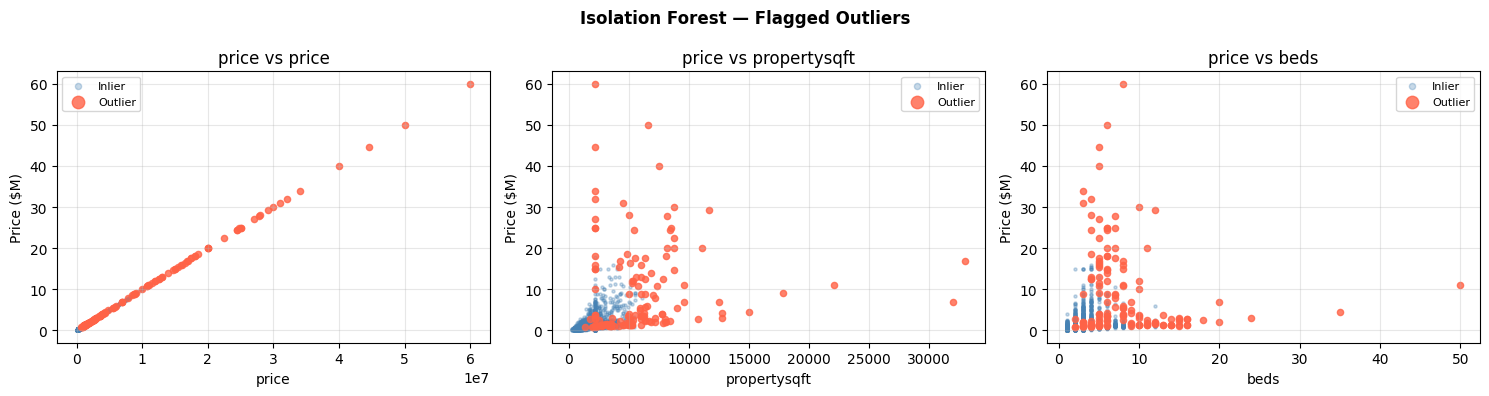

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["price", "propertysqft", "beds"]):
    ax.scatter(
        inliers[col],
        inliers["price"] / 1e6,
        s=5,
        alpha=0.3,
        color="steelblue",
        label="Inlier",
    )
    ax.scatter(
        outliers[col],
        outliers["price"] / 1e6,
        s=20,
        alpha=0.8,
        color="tomato",
        label="Outlier",
    )
    ax.set(xlabel=col, ylabel="Price ($M)", title=f"price vs {col}")
    ax.legend(markerscale=2, fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Isolation Forest — Flagged Outliers", fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
train_data = inliers.copy()
X_train_full = train_data.drop(columns="price")
y_train_full = train_data["price"]
print(f"Train shape after outlier removal: {train_data.shape}")

Train shape after outlier removal: (2651, 12)


137 training observations (5.0%) are flagged. The outlier summary confirms these are genuine extremes, up to 50 bedrooms and sqft above 10,000. The scatter plots show flagged points sitting in visually sparse regions, consistent with the algorithm's path-length logic.

## 4. Exploratory Data Analysis

### 4.1 Target Variable Distribution

Before feature analysis, the target variable distribution needs to be understood. Most regression algorithms assume roughly symmetric residuals, and fitting on a heavily skewed target amplifies the influence of extreme values on the loss function. Two candidate transformations are evaluated: log and Yeo-Johnson.

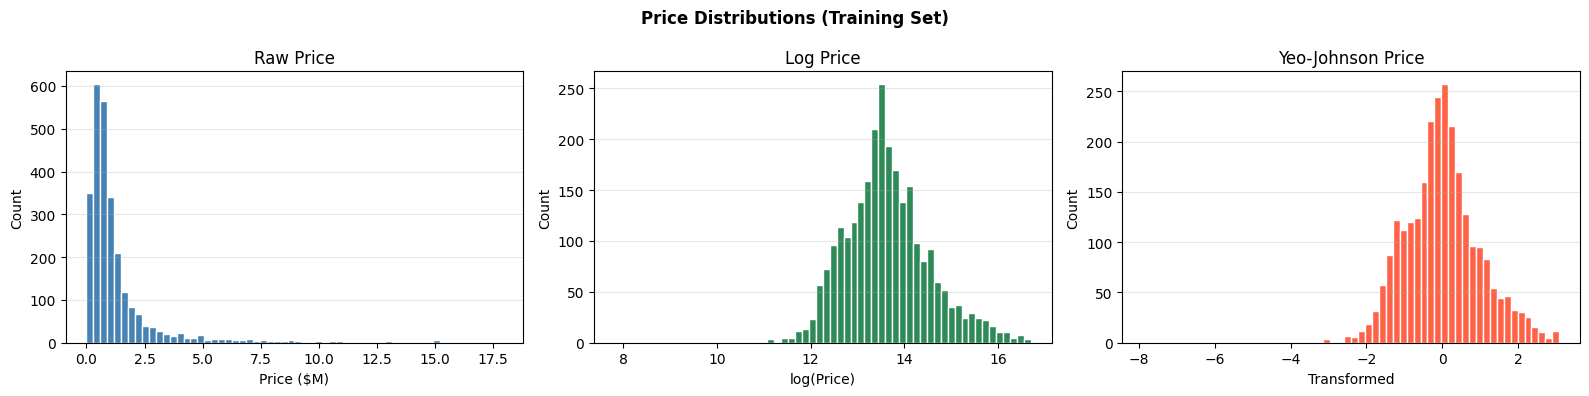

Skewness  raw=4.18  log=0.31  yeo-johnson=-0.05


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(train_data["price"] / 1e6, bins=60, color="steelblue", edgecolor="white")
axes[0].set(title="Raw Price", xlabel="Price ($M)", ylabel="Count")

log_prices = np.log1p(train_data["price"])
axes[1].hist(log_prices, bins=60, color="seagreen", edgecolor="white")
axes[1].set(title="Log Price", xlabel="log(Price)", ylabel="Count")

pt_tmp = PowerTransformer(method="yeo-johnson")
yj = pt_tmp.fit_transform(train_data[["price"]]).ravel()
axes[2].hist(yj, bins=60, color="tomato", edgecolor="white")
axes[2].set(title="Yeo-Johnson Price", xlabel="Transformed", ylabel="Count")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Price Distributions (Training Set)", fontweight="bold")
plt.tight_layout()
plt.show()

skew_raw = stats.skew(train_data["price"])
skew_log = stats.skew(np.log1p(train_data["price"]))
skew_yj = stats.skew(yj)
print(f"Skewness  raw={skew_raw:.2f}  log={skew_log:.2f}  yeo-johnson={skew_yj:.2f}")

Raw price skewness is 4.18. Log reduces it to 0.31; Yeo-Johnson reduces it further to -0.05. Despite the lower skewness, Yeo-Johnson is not used as the primary target transform for two reasons. First, prices are strictly positive, so its ability to handle negative values provides no advantage here. Second, log-transformed outputs are interpretable as percentage changes, which matters when explaining predictions.

Log transformation is used for linear models. Tree-based models receive Yeo-Johnson as the default, since they are scale-agnostic and the marginal skewness reduction can slightly smooth the loss surface.

### 4.2 Predictor Distributions

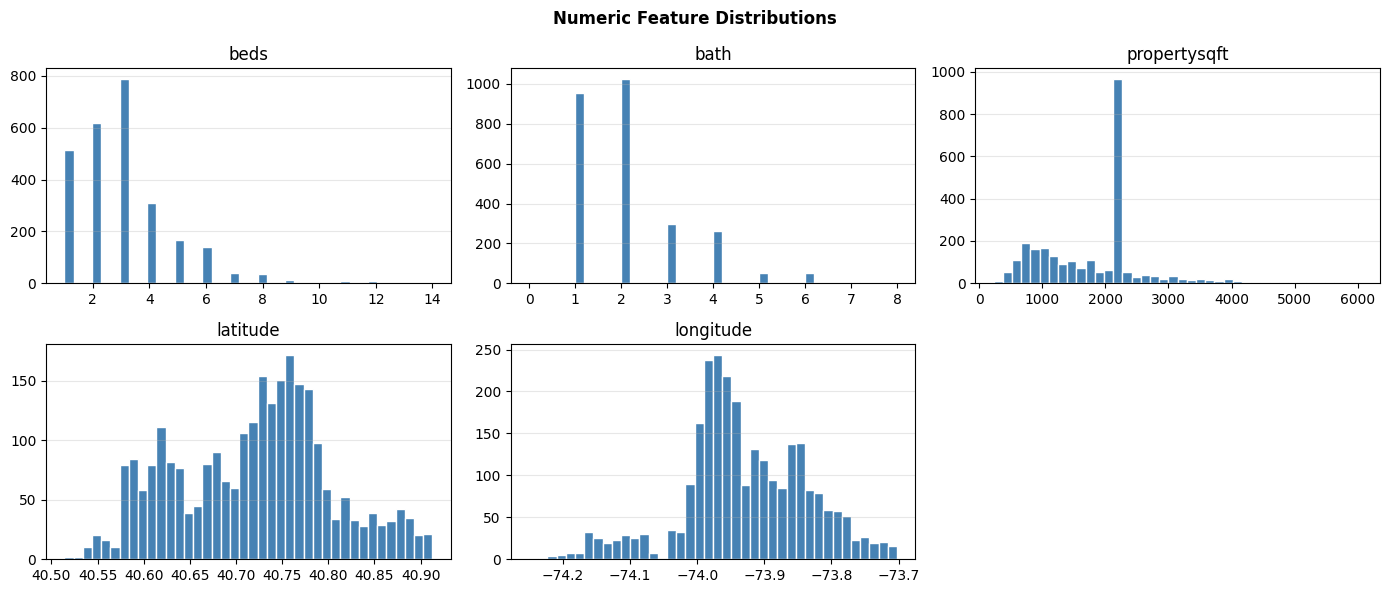

In [13]:
numeric_train = train_data.select_dtypes(include="number")
num_features = [c for c in numeric_train.columns if c != "price"]
n_cols = 3
n_rows = int(np.ceil(len(num_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.ravel()
for i, col in enumerate(num_features):
    axes[i].hist(
        numeric_train[col].dropna(), bins=40, color="steelblue", edgecolor="white"
    )
    axes[i].set_title(col)
    axes[i].grid(axis="y", alpha=0.3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Numeric Feature Distributions", fontweight="bold")
plt.tight_layout()
plt.show()

Beds and bath are right-skewed; most properties have two or three of each, with higher counts becoming rapidly rarer.

PROPERTYSQFT shows a sharp spike at ~2,184 sqft that spans the full price range. This is the imputation artifact from Section 2.2; hundreds of properties were assigned the dataset-wide median sqft, making them indistinguishable on that feature alone regardless of their actual size. The log-spaced size bins in Section 4.5 partially address this by converting the continuous column into a categorical tier.

Latitude and longitude show multimodal distributions reflecting the geographic clustering of listings in high-density neighbourhoods. This is why raw coordinates are weak linear predictors; the relationship between location and price is highly non-linear and local.

### 4.3 Price by Borough and Property Type

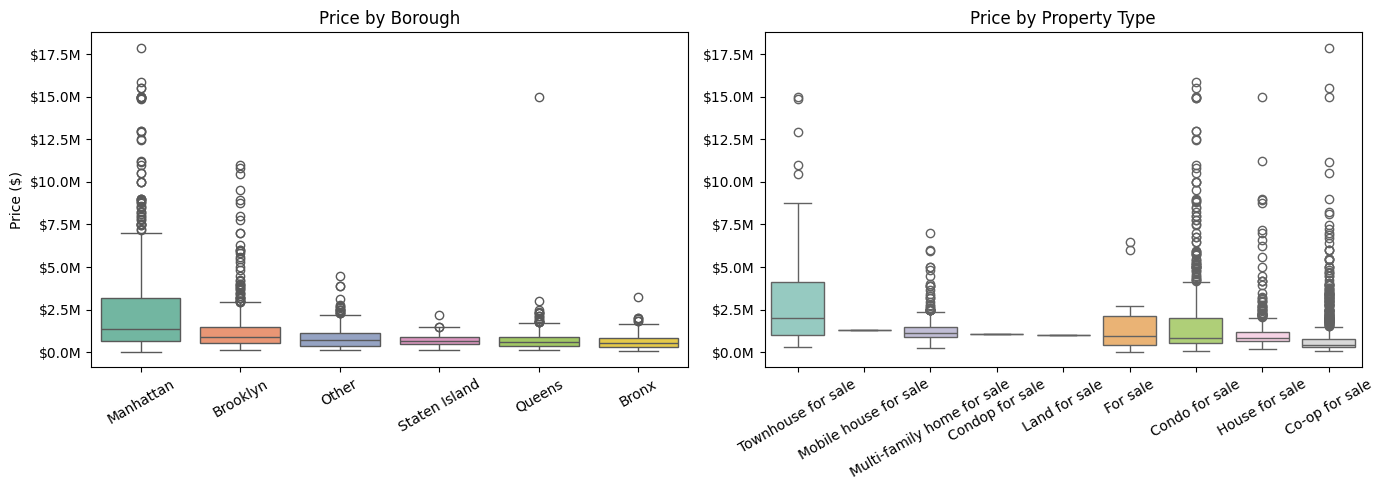

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

borough_order = (
    train_data.groupby("borough")["price"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=train_data,
    x="borough",
    y="price",
    order=borough_order,
    palette="Set2",
    ax=axes[0],
)
axes[0].set(title="Price by Borough", xlabel="", ylabel="Price ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[0].tick_params(axis="x", rotation=30)

pt_order = (
    train_data.groupby("type")["price"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=train_data,
    x="type",
    y="price",
    order=pt_order,
    palette="Set3",
    ax=axes[1],
)
axes[1].set(title="Price by Property Type", xlabel="", ylabel="")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Model Performance and Evaluation

The performance of the machine learning models was evaluated using several key metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared ($R^2$) score. These metrics provide a comprehensive understanding of how well the models predict house prices on unseen data. Lower MAE and MSE values indicate better predictive accuracy, while a higher R² score suggests that the model explains a greater proportion of the variance in the target variable.

The results from the evaluation process revealed that the Random Forest Regressor outperformed the other models, achieving the lowest MAE and MSE, as well as the highest R² score. This suggests that the Random Forest model is the most effective for predicting New York house prices in this study. However, it is important to note that model performance can vary depending on the specific characteristics of the dataset and the features used for training.

### Feature Importance

Understanding which features have the most significant impact on house prices is crucial for both model interpretation and practical decision-making. Feature importance analysis was conducted using the Random Forest model, which provides a ranking of features based on their contribution to the model's predictive power. The analysis revealed that location-related features, such as neighborhood and proximity to amenities, were among the most influential factors. Other important features included the number of bedrooms, square footage, and the age of the property. These insights can help stakeholders focus on the most critical factors when assessing property values or making investment decisions.

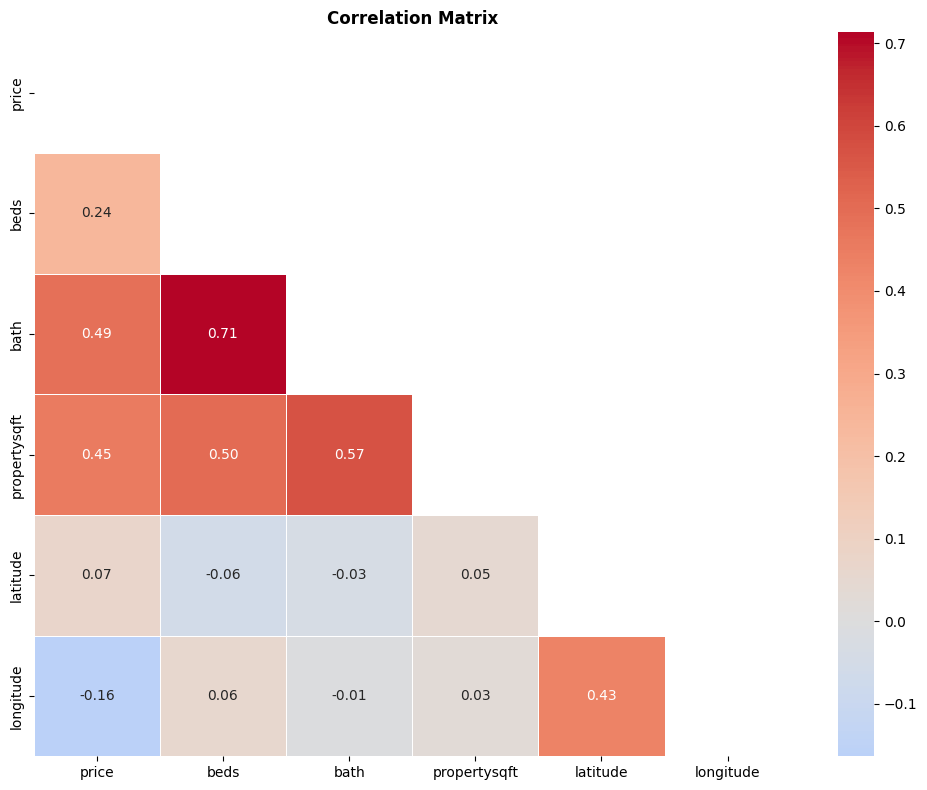

In [15]:
corr = numeric_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

The highest correlations with price are bath (0.49) and propertysqft (0.45).
Beds reach only 0.24, the market prices total volume and amenity count over
bedroom segmentation alone. Many expensive Manhattan properties are large
open-plan apartments with premium bathrooms rather than high bedroom counts.

Latitude and longitude correlate with price at 0.07 and -0.16 respectively.
These are weak linear relationships, which justifies the RBF spatial encoding
in Section 4.5, the location signal exists, but it is non-linear and
neighbourhood-specific.

Among predictors, bath and beds correlate at 0.71, and propertysqft correlates
at 0.57 with bath and 0.50 with beds. This multicollinearity is expected,
larger properties have more rooms. It is not a problem for tree-based models,
which split on one feature at a time, but regularisation is needed for the
linear baselines where inflated correlations can destabilise coefficient estimates.

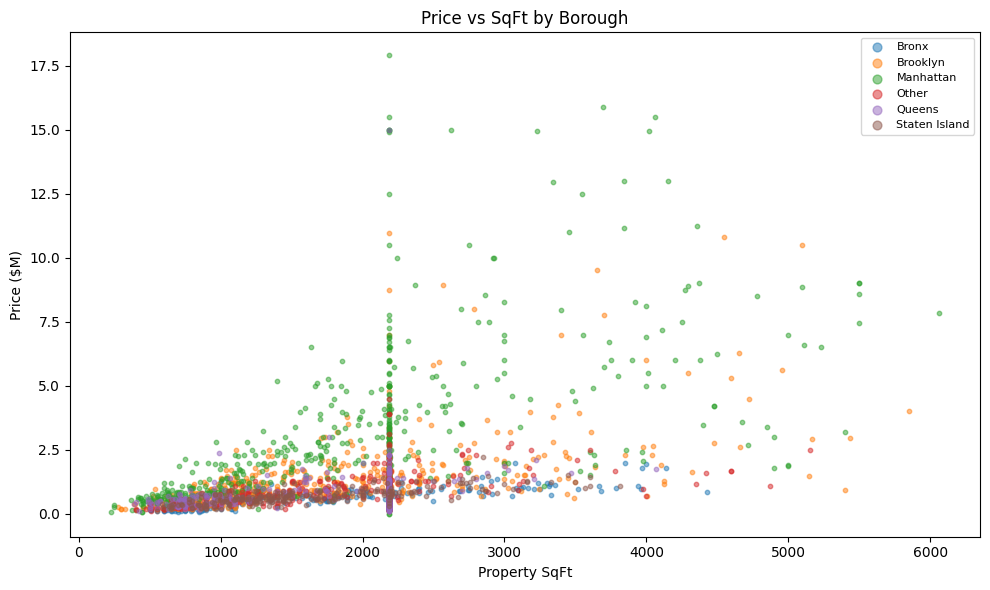

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for borough, grp in train_data.groupby("borough"):
    ax.scatter(grp["propertysqft"], grp["price"] / 1e6, label=borough, s=10, alpha=0.5)
ax.set(xlabel="Property SqFt", ylabel="Price ($M)", title="Price vs SqFt by Borough")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

The imputation spike at ~2,184 sqft is visible as a dense vertical band spanning almost the full price range. Properties from wildly different valuation tiers share an identical square footage reading, producing noise in any model that relies on sqft as a continuous predictor.

Manhattan's price-per-sqft slope is visibly steeper than any other borough, the same additional square footage commands a higher premium there than in Queens or Staten Island, which rules out a single market-wide price-per-sqft coefficient.

In [17]:
# Examine the spike
top_values = train_data['propertysqft'].value_counts().head(5)
print("Top 5 most frequent square footage values:")
print(top_values)

# We cannot drop all those values because they account for about 23% of the dataset,
# they also seem to be a result of mean imputation

Top 5 most frequent square footage values:
propertysqft
2184.207764    898
800.000000      42
900.000000      37
750.000000      37
1100.000000     26
Name: count, dtype: int64


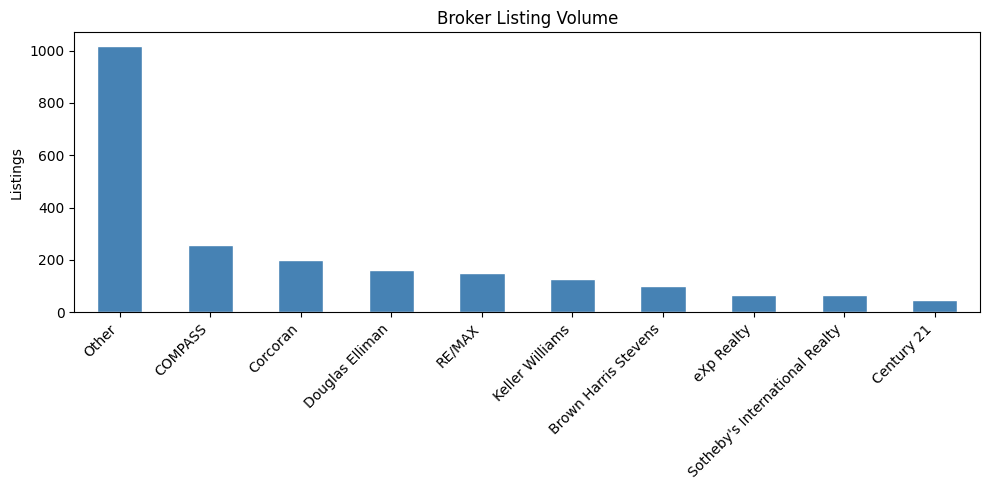

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
train_data["broker_name"].value_counts()[:10].plot.bar(
    ax=ax, color="steelblue", edgecolor="white"
)
ax.set(title="Broker Listing Volume", xlabel="", ylabel="Listings")

plt.xticks(rotation=45, ha="right") 

plt.tight_layout()
plt.show()

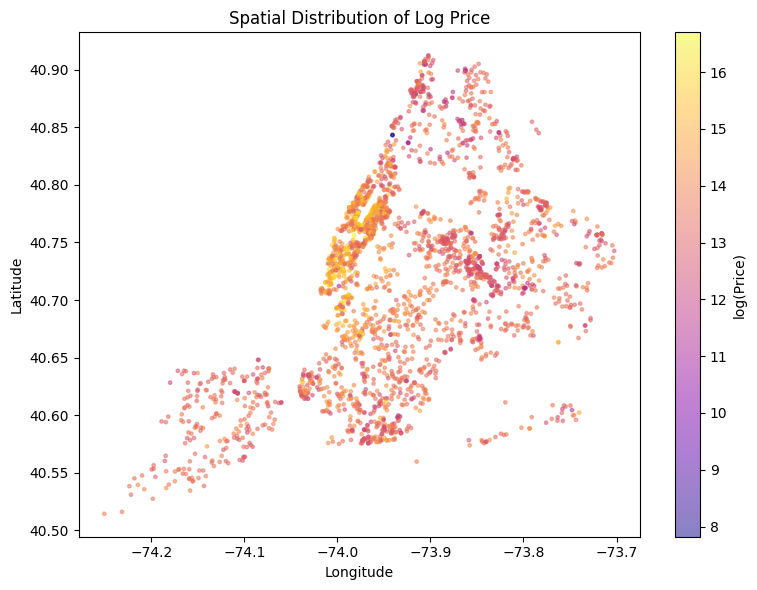

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    train_data["longitude"],
    train_data["latitude"],
    c=np.log1p(train_data["price"]),
    cmap="plasma",
    s=6,
    alpha=0.5,
)
plt.colorbar(sc, ax=ax, label="log(Price)")
ax.set(
    title="Spatial Distribution of Log Price",
    xlabel="Longitude",
    ylabel="Latitude",
)
plt.tight_layout()
plt.show()

The spatial price map shows a yellow cluster (highest log-price) at coordinates corresponding to central Manhattan, with purple (lowest) spreading outward to the peripheral boroughs. This is the spatial gradient the RBF encoding is designed to formalise, a continuous similarity to multiple neighbourhood centroids rather than a single linear trend across coordinate axes.

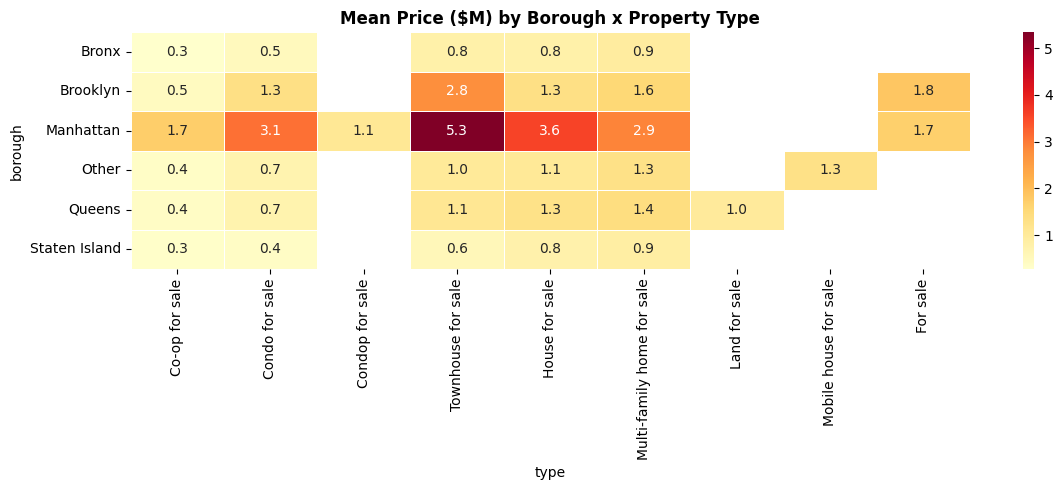

In [20]:
pivot = train_data.pivot_table(
    values="price",
    index="borough",
    columns="type",
    aggfunc="mean",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4, ax=ax)
ax.set_title("Mean Price ($M) by Borough x Property Type", fontweight="bold")
plt.tight_layout()
plt.show()

The borough-by-type heatmap shows strong interaction effects. Manhattan townhouses average $5.3M; the same category in Staten Island averages below $1M. Borough and type are not simply additive; their combination matters.

The heatmap also shows structural sparsity: condops appear only in Manhattan, land listings only in Queens. Models need to handle these rare combinations carefully at inference time.

### 4.5 Feature Engineering

Raw features have two main gaps. First, the spatial information is trapped in two continuous coordinates that have weak linear relationships with price but strong non-linear ones. Second, the broker and ZIP code columns are nominal identifiers; what matters is not which broker handled a listing, but how active that broker is in the market.

The `FeatureEngineer` class addresses both gaps while maintaining scikit-learn API compatibility so it can sit inside a Pipeline and respect the train/test boundary during cross-validation.

**Structural features.** `total_rooms` (beds + bath) and `bed_bath_ratio` summarise the internal layout. The correlation analysis showed these are more informative than the raw counts evaluated separately.

**Size discretisation.** PROPERTYSQFT is binned into five tiers using logarithmically-spaced edges: Tiny, Small, Medium, Large, Luxury. Log spacing means upper tiers span larger absolute ranges, appropriate for a right-skewed variable where a 500 to 1,000 sqft difference matters more than 10,000 to 15,000. This also naturally absorbs the imputation spike; all median-imputed properties land in the same bin.

**Leave-one-out frequency encoding.** Broker and ZIP code are encoded as listing count frequencies. The leave-one-out correction subtracts 1 from each observation's group count before merging, preventing the model from looking up its own contribution during cross-validation fold evaluation.

**RBF spatial encoding.** K-Means is fitted to latitude/longitude to find 10 geographic centroids. Each property is then encoded as its RBF kernel similarity to each centroid; a 10-dimensional continuous vector. Using similarities rather than cluster labels avoids treating an ordinal-like cluster ID as a continuous magnitude, which scalers would do incorrectly.

In [21]:
@dataclass
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Scikit-learn compatible transformer that adds derived features.

    New columns added by transform():
    - bed_bath_ratio, total_rooms: layout summaries
    - size_category: log-spaced sqft bins (Tiny to Luxury)
    - broker_listing_count, zip_listing_count: leave-one-out frequency counts
    - cluster_sim_0 .. cluster_sim_{n_clusters-1}: RBF similarity to geo centroids

    The leave-one-out subtraction in fit() prevents the count features from
    leaking target information during cross-validation.
    """

    bins: np.ndarray = field(
        default_factory=lambda: np.logspace(np.log10(200), np.log10(65000), num=6)
    )
    labels: list[str] = field(
        default_factory=lambda: ["Tiny", "Small", "Medium", "Large", "Luxury"]
    )
    cluster_features: list[str] = field(
        default_factory=lambda: ["latitude", "longitude"]
    )
    n_clusters: int = 10
    gamma: float = 1.0
    random_state: int = 42

    def fit(self, X, y=None, **fit_params):
        sample_weight = fit_params.get("sample_weight", None)
        X = X.copy()

        # Leave-one-out: subtract 1 so a held-out observation doesn't count itself.
        self.broker_stats_ = (
            X.groupby("broker_name")
            .size()
            .sub(1)
            .clip(lower=0)
            .to_frame("broker_listing_count")
        )
        self.zip_stats_ = (
            X.groupby("zip_code")
            .size()
            .sub(1)
            .clip(lower=0)
            .to_frame("zip_listing_count")
        )

        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters, random_state=self.random_state
        )
        kw = {"sample_weight": sample_weight} if sample_weight is not None else {}
        self.kmeans_.fit(X[self.cluster_features], **kw)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X["bed_bath_ratio"] = X["beds"] / X["bath"].replace(0, np.nan)
        X["total_rooms"] = X["beds"] + X["bath"]
        X["size_category"] = pd.cut(
            X["propertysqft"],
            bins=self.bins,
            labels=self.labels,
            include_lowest=True,
            right=False,
        )
        X = X.merge(
            self.broker_stats_, left_on="broker_name", right_index=True, how="left"
        )
        X = X.merge(self.zip_stats_, left_on="zip_code", right_index=True, how="left")
        X["broker_listing_count"] = X["broker_listing_count"].fillna(0)
        X["zip_listing_count"] = X["zip_listing_count"].fillna(0)

        # RBF similarity to each centroid, continuous spatial encoding that avoids
        # treating cluster IDs as ordinal magnitudes.
        similarities = rbf_kernel(
            X[self.cluster_features], self.kmeans_.cluster_centers_, gamma=self.gamma
        )
        for i in range(similarities.shape[1]):
            X[f"cluster_sim_{i}"] = similarities[:, i]
        return X

    def get_feature_names_out(self, input_features=None):
        sim_cols = [f"cluster_sim_{i}" for i in range(self.n_clusters)]
        new = [
            "bed_bath_ratio",
            "total_rooms",
            "size_category",
            "broker_listing_count",
            "zip_listing_count",
            *sim_cols,
        ]
        return list(input_features) + new if input_features is not None else new

### 4.6 Mutual Information: Before and After Feature Engineering

Mutual information (MI) quantifies how much knowing a feature reduces uncertainty about the target. Unlike Pearson correlation, it captures non-linear dependencies. It is computed before and after feature engineering to verify that the new features carry more information than the raw columns they were derived from.

In [22]:
def make_mi_scores(X, y, random_state=42):
    """Return a sorted Series of mutual information scores against target y."""
    X = X.copy()
    X = X.loc[:, ~X.columns.str.contains("price", case=False)]
    int_types = {np.dtype(t) for t in ("int8", "int16", "int32", "int64")}
    discrete = X.dtypes.apply(lambda dt: dt in int_types)
    for col in X.select_dtypes(["object", "category"]):
        X[col], _ = X[col].factorize()
    X = X.fillna(0)
    mi = mutual_info_regression(
        X, y, discrete_features=discrete, random_state=random_state
    )
    return pd.Series(mi, index=X.columns, name="MI Score").sort_values(ascending=False)


def plot_mi_scores(scores, top_n=15, title="Mutual Information Scores"):
    plot_scores = scores.head(top_n).sort_values()
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(plot_scores)))  # type: ignore
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_scores.plot.barh(ax=ax, color=colors)
    ax.set(title=title, xlabel="MI Score")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

In [ ]:
mi_before = make_mi_scores(X_train_full, y_train_full)
plot_mi_scores(mi_before, title="MI Scores - Before Feature Engineering")

In [ ]:
fe_check = FeatureEngineer()
fe_check.fit(X_train_full)
train_fe = fe_check.transform(X_train_full)

mi_after = make_mi_scores(train_fe, y_train_full)
plot_mi_scores(mi_after, title="MI Scores - After Feature Engineering")

Before engineering, bath and sublocality lead the MI rankings, followed by sqft and type. Raw coordinates and broker name have the weakest scores.

After engineering, `total_rooms` enters at third position (~0.33 MI), above raw sqft and type. Several cluster similarity columns land in the top tier, clearly outranking raw lat/lon. The zip listing count scores higher than the raw zip string. All of this confirms that the engineering decisions were justified, the new features carry more information than the raw columns they replaced.

### 4.7 Preprocessing Pipeline

The preprocessing step converts the engineered feature matrix into a numeric array suitable for all candidate models. Four sub-pipelines handle different feature groups:

- **Yeo-Johnson:** applied to PROPERTYSQFT, which retains right skew even after outlier removal.
- **RobustScaler:** applied to continuous numeric features. RobustScaler uses the IQR rather than standard deviation, making it less sensitive to residual extreme values in count features like `broker_listing_count`.
- **OrdinalEncoder:** applied to `size_category`, preserving the ordinal ordering from Tiny to Luxury.
- **OneHotEncoder:** applied to nominal categoricals (borough, broker_name, type, zip_code). `handle_unknown="ignore"` ensures unseen labels at inference produce a zero vector rather than an error.

In [25]:
class SanitiseFeatureNames(BaseEstimator, TransformerMixin):
    """Replace characters that LightGBM rejects with underscores."""

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in X.columns]
        return X

In [26]:
cluster_sim_features = [f"cluster_sim_{i}" for i in range(10)]

yeojohnson_features = ["propertysqft"]
numeric_features = [
    "beds",
    "bath",
    "latitude",
    "longitude",
    "bed_bath_ratio",
    "total_rooms",
    "broker_listing_count",
    "zip_listing_count",
    *cluster_sim_features,
]
ordinal_features = ["size_category"]
categorical_features = ["borough", "broker_name", "type", "zip_code"]

yeojohnson_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    PowerTransformer(method="yeo-johnson"),
)
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
)
ordinal_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=[["Tiny", "Small", "Medium", "Large", "Luxury"]]),
)
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Unknown"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("yeo", yeojohnson_pipeline, yeojohnson_features),
        ("num", numeric_pipeline, numeric_features),
        ("ord", ordinal_pipeline, ordinal_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")


def build_pipeline(regressor, target_transformer=None):
    """
    Assemble the full end-to-end pipeline for a given regressor.

    Default target transformer is Yeo-Johnson; pass log_transformer for
    linear models that benefit from the interpretability of log-price.
    """
    if target_transformer is None:
        target_transformer = PowerTransformer(method="yeo-johnson")
    return Pipeline(
        [
            ("fe", FeatureEngineer()),
            ("pre", preprocessor),
            ("sanitise", SanitiseFeatureNames()),
            (
                "model",
                TransformedTargetRegressor(
regressor=regressor,
transformer=target_transformer,
                ),
            ),
        ]
    )


log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

## 5. Model Selection and Training

### 5.1 Baseline Comparison

Ten candidate models are evaluated under identical conditions before any hyperparameter tuning. The evaluation uses 5-fold repeated cross-validation (3 repeats, 15 total folds) on the training set. Each fold fits the entire pipeline; feature engineering, preprocessing, and the model; from scratch, so no information from the validation fold influences any fitted transformer.

**Why MAPE?** Mean Absolute Percentage Error normalises by the actual price. A $50,000 prediction error has different implications for a $200,000 property than for a $5M one. MAPE treats both proportionally, making it the natural error metric for a price prediction task with a wide value range.

Linear models use log price as the target transform. Tree-based models use Yeo-Johnson since trees are scale-agnostic and the marginal skewness reduction can help the learning dynamics.

In [27]:
baseline_models = {
    "Linear Regression": (LinearRegression(), log_transformer),
    "Ridge": (Ridge(alpha=1.0), log_transformer),
    "Lasso": (Lasso(alpha=0.001), log_transformer),
    "ElasticNet": (ElasticNet(alpha=0.001, l1_ratio=0.5), log_transformer),
    "SVR": (SVR(kernel="rbf", C=10, epsilon=0.1), log_transformer),
    "Random Forest": (
        RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
        None,
    ),
    "Hist GB": (
        HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, random_state=42
        ),
        None,
    ),
    "LightGBM": (
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            n_jobs=-1,
            random_state=42,
            verbose=0,
            device="gpu",
        ),
        None,
    ),
    "XGBoost": (
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            n_jobs=-1,
            random_state=42,
            verbosity=0,
            tree_method="hist",
            device="cuda",
        ),
        None,
    ),
    "CatBoost": (
        CatBoostRegressor(
            iterations=400,
            learning_rate=0.05,
            random_seed=42,
            verbose=0,
            task_type="GPU",
            devices="0",
        ),
        None,
    ),
}

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_results = []

for name, (model, t) in baseline_models.items():
    pipe = build_pipeline(model, target_transformer=t)
    scores = -cross_val_score(
        pipe,
        X_train_full,
        y_train_full,
        scoring="neg_mean_absolute_percentage_error",
        cv=cv,
        n_jobs=1,  # boosters manage their own parallelism on GPU
    )
    cv_results.append(
        {"Model": name, "CV MAPE Mean": scores.mean(), "CV MAPE Std": scores.std()}
    )
    print(f"{name:25s}  MAPE={scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("CV MAPE Mean")
print("\n", cv_df.to_string(index=False))

Linear Regression          MAPE=0.3835 ± 0.0332
Ridge                      MAPE=0.3875 ± 0.0441
Lasso                      MAPE=0.4168 ± 0.0628
ElasticNet                 MAPE=0.4068 ± 0.0609
SVR                        MAPE=0.3190 ± 0.0521
Random Forest              MAPE=0.2761 ± 0.0124
Hist GB                    MAPE=0.2697 ± 0.0130


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM                   MAPE=0.2668 ± 0.0114
XGBoost                    MAPE=0.2601 ± 0.0132
CatBoost                   MAPE=0.2636 ± 0.0142

             Model  CV MAPE Mean  CV MAPE Std
          XGBoost      0.260083     0.013193
         CatBoost      0.263594     0.014154
         LightGBM      0.266835     0.011370
          Hist GB      0.269683     0.012959
    Random Forest      0.276053     0.012416
              SVR      0.318951     0.052081
Linear Regression      0.383546     0.033246
            Ridge      0.387472     0.044148
       ElasticNet      0.406799     0.060928
            Lasso      0.416776     0.062774


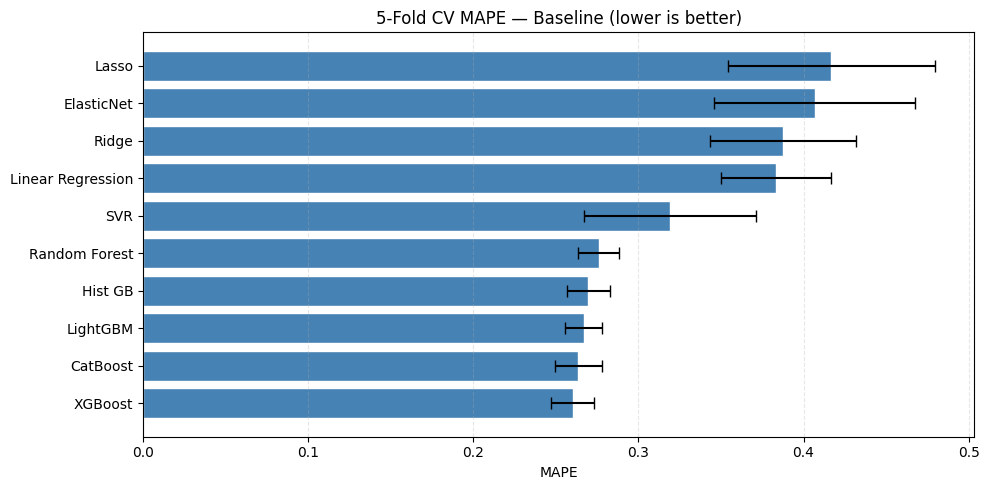

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    cv_df["Model"],
    cv_df["CV MAPE Mean"],
    xerr=cv_df["CV MAPE Std"],
    color="steelblue",
    edgecolor="white",
    capsize=4,
)
ax.set(title="5-Fold CV MAPE — Baseline (lower is better)", xlabel="MAPE")
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

### 5.2 Baseline Results

The results divide cleanly into three performance tiers.

**Linear models (MAPE 0.39-0.42):** All four linear regressors cluster near 0.40 with high fold variance (std ~0.05-0.06). The EDA showed that the relationship between price and location is non-linear, and that the most informative predictors have curved relationships with price even after log transformation. Linear models approximate these curves poorly regardless of regularisation strength.

**SVR (MAPE 0.32):** The RBF kernel gives SVR a non-linear advantage over the linear family, but it remains a single-kernel smoother and cannot match the flexibility of an ensemble of trees. Its fold variance is also high.

**Gradient boosting models (MAPE 0.26-0.27):** The four tree ensembles separate from the rest of the field. Random Forest provides a solid baseline at 0.276053. The histogram-based boosters, XGBoost (0.260083), LightGBM (0.266835), CatBoost (0.263594), and Hist GB, all perform within ~1 percentage point of each other with low fold variance (std ~0.01). These four proceed to hyperparameter tuning.

### 5.3 Hyperparameter Tuning

Gradient boosting models have many interacting hyperparameters. Grid search across this space is computationally impractical; even a modest 5-point grid over 8 parameters requires 390,625 evaluations, each involving a full cross-validation.

Optuna's Tree-structured Parzen Estimator (TPE) is used instead. TPE is a Bayesian optimisation algorithm that maintains two probability models: one over parameter configurations that produced the best results so far, and one over the rest. New trials are sampled by maximising the ratio of the "good" model to the "bad" model, concentrating the search in productive regions of the parameter space. In practice, TPE finds good solutions in 50 to 100 trials where grid search would require thousands.

Tuning uses a single-repeat 5-fold CV to keep wall time reasonable. Each model receives 50 trials.

Two implementation notes: LightGBM is tuned on CPU despite GPU being available; at ~2,600 training rows, data transfer overhead exceeds the compute savings. XGBoost uses CUDA, where this overhead is lower. CatBoost uses CPU for the tuning phase to avoid the `bagging_temperature`/`subsample` mutual exclusion that affects some GPU builds.

In [29]:
TUNE_CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=42)
N_TRIALS = 50


def _cv_mape(pipe) -> float:
    scores = -cross_val_score(
        pipe,
        X_train_full,
        y_train_full,
        scoring="neg_mean_absolute_percentage_error",
        cv=TUNE_CV,
        n_jobs=1,
    )
    return scores.mean()


def lgbm_objective(trial: optuna.Trial) -> float:
    # LightGBM GPU is slower than CPU at ~3k rows due to transfer overhead.
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "n_jobs": -1,
        "random_state": 42,
        "verbose": -1,
    }
    return _cv_mape(build_pipeline(LGBMRegressor(**params)))


def xgb_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": 42,
        "verbosity": 0,
        "tree_method": "hist",
        "device": "cuda",
    }
    return _cv_mape(build_pipeline(XGBRegressor(**params)))


def catboost_objective(trial: optuna.Trial) -> float:
    # bagging_temperature and subsample are mutually exclusive, conditional on
    # bootstrap_type to avoid invalid parameter combinations.
    bootstrap_type = trial.suggest_categorical(
        "bootstrap_type", ["Bayesian", "Bernoulli"]
    )
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-4, 10.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "bootstrap_type": bootstrap_type,
        "random_seed": 42,
        "verbose": 0,
    }
    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float(
            "bagging_temperature", 0.0, 1.0
        )
    else:
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
    return _cv_mape(build_pipeline(CatBoostRegressor(**params)))


def histgb_objective(trial: optuna.Trial) -> float:
    params = {
        "max_iter": trial.suggest_int("max_iter", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 20, 200),
        "l2_regularization": trial.suggest_float(
            "l2_regularization", 1e-4, 10.0, log=True
        ),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
        "random_state": 42,
    }
    return _cv_mape(build_pipeline(HistGradientBoostingRegressor(**params)))

In [ ]:
objectives = {
    "LightGBM": lgbm_objective,
    "XGBoost": xgb_objective,
    "CatBoost": catboost_objective,
    "Hist GB": histgb_objective,
}

studies: dict[str, optuna.Study] = {}

for name, objective in objectives.items():
    print(f"\nTuning {name} ...")
    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=42),
        study_name=name,
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f"best MAPE: {study.best_value:.4f}")
    print(f"best params: {study.best_params}")


Tuning LightGBM ...


  0%|          | 0/50 [00:00<?, ?it/s]

best MAPE: 0.2579
best params: {'n_estimators': 269, 'learning_rate': 0.17285761149148882, 'num_leaves': 80, 'max_depth': 5, 'min_child_samples': 11, 'subsample': 0.6624057797568982, 'colsample_bytree': 0.7698100534013989, 'reg_alpha': 0.07232089166539443, 'reg_lambda': 9.050657950692411}

Tuning XGBoost ...


  0%|          | 0/50 [00:00<?, ?it/s]

best MAPE: 0.2588
best params: {'n_estimators': 997, 'learning_rate': 0.04118389488405202, 'max_depth': 5, 'min_child_weight': 20, 'subsample': 0.7804533509078435, 'colsample_bytree': 0.8513496163789993, 'gamma': 0.055111967492394796, 'reg_alpha': 0.07352836149311404, 'reg_lambda': 0.09086950863125914}

Tuning CatBoost ...


  0%|          | 0/50 [00:00<?, ?it/s]

best MAPE: 0.2477
best params: {'bootstrap_type': 'Bernoulli', 'iterations': 907, 'learning_rate': 0.029764698959900485, 'depth': 7, 'l2_leaf_reg': 0.020918208314012778, 'min_data_in_leaf': 32, 'subsample': 0.8366733523272174}

Tuning Hist GB ...


  0%|          | 0/50 [00:00<?, ?it/s]

### 5.4 Tuning Results

After 50 TPE trials each, the tuned cross-validation MAPEs are:

| Model | Tuned CV MAPE | Key parameters |
|---|---|---|
| LightGBM | 0.257857 | 269 estimators, lr=0.18, depth=5 |
| XGBoost | 0.258812 | 997 estimators, lr=0.04, depth=5 |
| Hist GB | 0.2604 | 937 iterations, lr=0.039 |
| **CatBoost** | **0.247725** | 907 iterations, lr=0.02976, depth=7, Bernoulli |

CatBoost leads the tuning phase. All four models fall within ~1 percentage point of each other, which makes ensembling worthwhile, they are close enough to combine, but different enough in their internal mechanics to produce partially uncorrelated errors.

### 5.5 Ensembling

A VotingRegressor combines the four tuned pipelines by averaging their predictions. Equal weights are used because all four models have similar tuned performance. Assigning non-equal weights would require calibrating them on a second held-out validation set; estimating weights from the same data the models were trained on would overfit the ensemble to that data. Given the dataset size, a second hold-out is not practical here.

In [41]:
def build_tuned_pipeline(name: str) -> Pipeline:
    """Rebuild a pipeline using the best params found for `name` by Optuna."""
    p = studies[name].best_params
    constructors = {
        "LightGBM": lambda: LGBMRegressor(**p, n_jobs=-1, random_state=42, verbose=-1),
        "XGBoost": lambda: XGBRegressor(
            **p,
            n_jobs=-1,
            random_state=42,
            verbosity=0,
            tree_method="hist",
            device="cuda",
        ),
        "CatBoost": lambda: CatBoostRegressor(
            **p, random_seed=42, verbose=0, task_type="GPU", devices="0"
        ),
        "Hist GB": lambda: HistGradientBoostingRegressor(**p, random_state=42),
    }
    return build_pipeline(constructors[name]())

In [42]:
tuned_pipes = {name: build_tuned_pipeline(name) for name in studies}

for name, pipe in tuned_pipes.items():
    pipe.fit(X_train_full, y_train_full)
    print(f"{name} fitted")

# Equal-weight averaging: all four models are within ~1 MAPE point of each other
# after tuning. Calibrating weights would require a second hold-out set.
ensemble = VotingRegressor(
    estimators=[(name, pipe) for name, pipe in tuned_pipes.items()],
    n_jobs=1,
)
ensemble.fit(X_train_full, y_train_full)

LightGBM fitted
XGBoost fitted
CatBoost fitted
Hist GB fitted


VotingRegressor(estimators=[('LightGBM',
                             Pipeline(steps=[('fe',
                                              FeatureEngineer(bins=array([  200.        ,   635.92612632,  2022.0101907 ,  6429.2455398 ,
       20442.62605652, 65000.        ]),
                                                              labels=['Tiny',
                                                                      'Small',
                                                                      'Medium',
                                                                      'Large',
                                                                      'Luxury'],
                                                              cluster_features=['latitude',
                                                                                'longitude'],
                                                              n_clusters=10,
                                                              gamma=1.0,
                                                              random_state=42)),
                                             ('pre',
                                              ColumnTransformer(transformers=[('yeo',
                                                                               Pipeline(ste...
                                                                verbose_feature_names_out=False)),
                                             ('sanitise',
                                              SanitiseFeatureNames()),
                                             ('model',
                                              TransformedTargetRegressor(regressor=HistGradientBoostingRegressor(l2_regularization=1.3312961840633524,
                                                                                                                 learning_rate=0.04808975853896442,
                                                                                                                 max_depth=6,
                                                                                                                 max_features=0.716852767217316,
                                                                                                                 max_iter=801,
                                                                                                                 max_leaf_nodes=61,
                                                                                                                 min_samples_leaf=18,
                                                                                                                 random_state=42),
                                                                         transformer=PowerTransformer()))]))],
                n_jobs=1)

## 6. Results

### 6.1 Hold-out Test Performance

The test set has been untouched until this point. All model selection, outlier removal, feature engineering decisions, and hyperparameter choices were made using cross-validation on the training set only. The following metrics are the final reported performance of this project.

In [43]:
results = {}
for name, pipe in tuned_pipes.items():
    mape = mean_absolute_percentage_error(y_test, pipe.predict(X_test))
    results[name] = mape
    print(f"{name:12s}  test MAPE: {mape:.4f}")

ensemble_mape = mean_absolute_percentage_error(y_test, ensemble.predict(X_test))
results["Ensemble"] = ensemble_mape
print(f"{'Ensemble':12s}  test MAPE: {ensemble_mape:.4f}")

LightGBM      test MAPE: 0.2726
XGBoost       test MAPE: 0.2555
CatBoost      test MAPE: 0.2644
Hist GB       test MAPE: 0.2512
Ensemble      test MAPE: 0.2432


Individual test MAPEs: LightGBM 0.2726, Hist GB 0.2512, CatBoost 0.2644, XGBoost 0.2555. The ensemble lands at **0.2432**, beating the best individual model by ~0.008. Averaging smooths out cases where one model over- or under-shoots.

The individual test rankings differ from the cross-validation rankings; CatBoost led CV but is fourth on the test set. This is expected at this dataset size; the variance of a single hold-out evaluation is higher than a repeated CV, so small rank differences are not meaningful.

### 6.2 Residual Diagnostics

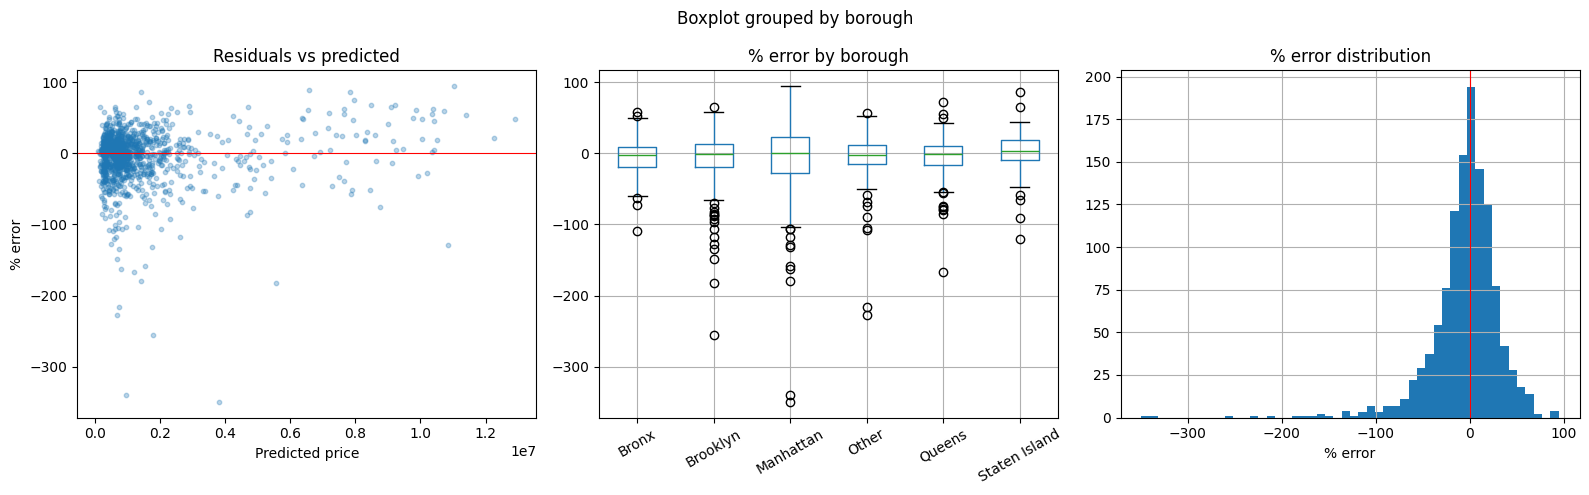

In [47]:
y_pred = ensemble.predict(X_test)
residuals = y_test - y_pred
pct_error = (residuals / y_test) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_pred, pct_error, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_xlabel("Predicted price")
axes[0].set_ylabel("% error")
axes[0].set_title("Residuals vs predicted")

test_df = X_test.copy()
test_df["pct_error"] = pct_error
test_df.boxplot(column="pct_error", by="borough", ax=axes[1], rot=30)
axes[1].set_title("% error by borough")
axes[1].set_xlabel("")

pd.Series(pct_error).hist(bins=50, ax=axes[2])
axes[2].axvline(0, color="red", linewidth=0.8)
axes[2].set_title("% error distribution")
axes[2].set_xlabel("% error")

plt.tight_layout()
plt.show()

The error distribution is sharply peaked at zero, with a heavier left tail than right. A negative percentage error means the model predicted higher than the actual price. These overestimates extend to around -300% in isolated cases, but are not a systemic pattern.

The borough boxplots show a median near zero for all boroughs, confirming no directional bias by location. Error spread is wider for Manhattan and Brooklyn than for the outer boroughs, reflecting the greater difficulty of pricing markets where unobserved factors; floor level, views, building amenities, renovation quality; drive large price differences the available features cannot capture.

### 6.3 Feature Importance

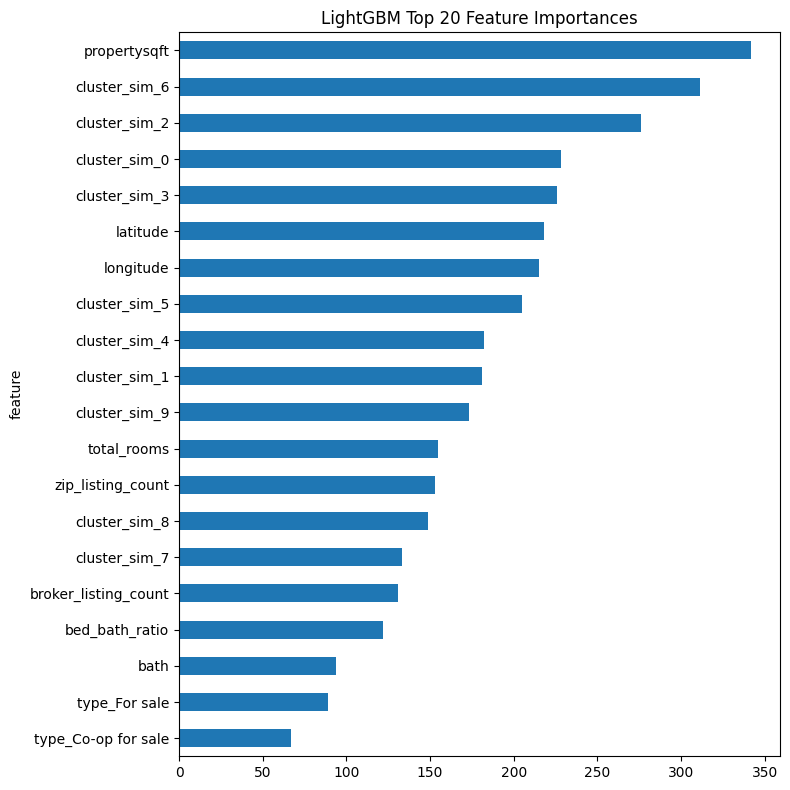

In [48]:
lgbm_pipe = tuned_pipes["LightGBM"]
lgbm_pipe.fit(X_train_full, y_train_full)

feature_names = lgbm_pipe.named_steps["pre"].get_feature_names_out()
importances = lgbm_pipe.named_steps["model"].regressor_.feature_importances_

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

imp_df.plot(kind="barh", x="feature", y="importance", figsize=(8, 8), legend=False)
plt.gca().invert_yaxis()
plt.title("LightGBM Top 20 Feature Importances")
plt.tight_layout()
plt.show()

PROPERTYSQFT is the most-used splitting feature by a clear margin. Several cluster similarity columns rank in the top five; cluster_sim_6, cluster_sim_0, and cluster_sim_2 all appear above raw latitude and longitude. This confirms that the RBF spatial encoding was useful: the model finds the continuous similarity vectors more informative than the raw coordinates they derived from, because similarities encode proximity to specific high-value geographic clusters rather than abstract coordinate values.

Sublocality and borough also rank highly, confirming that administrative boundaries carry independent signal beyond what the spatial features capture.

### 6.4 Calibration Metrics

In [49]:
print(f"mean signed error  : {pct_error.mean():.2f}%")
print(f"median signed error: {np.median(pct_error):.2f}%")
print(f"% within 10%: {(np.abs(pct_error) <= 10).mean()*100:.1f}%")
print(f"% within 20%: {(np.abs(pct_error) <= 20).mean()*100:.1f}%")

mean signed error  : -5.20%
median signed error: -0.54%
% within 10%: 33.0%
% within 20%: 58.1%


In [50]:
test_df = X_test.copy()
test_df["pct_error"] = pct_error
test_df["abs_pct_error"] = np.abs(pct_error)

for grp_col in ["borough", "type"]:
    print(
        test_df.groupby(grp_col)["abs_pct_error"]
        .agg(["mean", "median", "count"])
        .round(2)
    )
    print()

                mean  median  count
borough                            
Bronx          18.47   15.52    123
Brooklyn       24.11   16.24    272
Manhattan      32.61   23.64    355
Other          19.61   13.14    179
Queens         19.34   12.63    138
Staten Island  19.46   14.53    130

                             mean  median  count
type                                            
Co-op for sale              26.11   18.03    416
Condo for sale              25.14   17.30    233
Condop for sale             36.15   36.15      2
Townhouse for sale          25.07   18.19     71
House for sale              23.42   15.96    278
Multi-family home for sale  20.49   15.05    193
Land for sale                 NaN     NaN      0
Mobile house for sale         NaN     NaN      0
For sale                    20.53   17.86      4



The median signed error is -0.54%, meaning the model is nearly unbiased at the median. The mean of -5.20% is pulled left by a small number of large overpredictions. 33% of predictions fall within 10% of the actual price, and 58% within 20%.

**By borough:** The model performs best on Queens and Staten Island (median absolute error ~13%). Manhattan is the hardest market, with a median absolute error of 24%. The gap likely reflects luxury-specific factors; building prestige, floor level, views, concierge services; that are absent from the dataset.

**By property type:** Multi-family homes and standard houses are the most predictable (~20 to 23% mean error). Co-ops are harder, which is consistent with their pricing being partly determined by proprietary board approval processes that affect transaction prices in ways not captured by structural features. The condop category shows 36% mean error, but with only two test observations this number is not statistically meaningful.

## 7. Conclusion

### 7.1 Summary of Findings

This project built a supervised learning pipeline for NYC house price prediction, starting from a raw dataset with several data quality problems and producing a validated ensemble model with a hold-out test MAPE of 24.32%.

**Data quality matters more than model complexity at this scale.** Removing the sentinel values, corrupt bath rows, and non-transactional listings was necessary to prevent the model from fitting to noise. Each removal decision was explicit and justified by a concrete data quality reason.

**Feature engineering carried measurable signal.** Total rooms, RBF spatial similarities, and frequency-encoded broker/ZIP features all increased mutual information scores over the raw columns they replaced. The cluster similarity features ranked above raw coordinates in LightGBM's feature importance, confirming the spatial encoding did genuine work beyond what coordinates alone provide.

**Gradient boosting models outperformed linear methods substantially.** The best linear model (Linear Regression) achieved a CV MAPE of 0.383546 versus 0.276053 for the weakest gradient booster (Random Forest, untuned). The non-linear tree structure is better suited to a dataset where price is driven by location gradients and category interactions rather than simple additive effects.

**Ensembling provided a small but consistent improvement.** The voting ensemble at 24.32% test MAPE outperformed all four individual models. This worked because the four base models differ in their internal mechanics; CatBoost, XGBoost, LightGBM, and Hist GB each handle gradient computation, regularisation, and tree construction differently; so their prediction errors are not perfectly correlated.

**Manhattan remains the hardest market to price.** Median absolute errors are roughly double those for the outer boroughs, reflecting the density of unobserved luxury and building-specific factors in that market.

### 7.2 Limitations

The dataset's main limitation is the square footage imputation artifact. A large fraction of properties share an identical sqft value equal to the dataset-wide median. Log-spaced discretisation partially mitigates this, but a dataset with accurately recorded areas would produce meaningfully better results.

The model also lacks features known to drive NYC prices: floor level, building age, proximity to subway stations, school district quality, and days on market. Adding any of these would likely improve accuracy, particularly for Manhattan where the model currently struggles most.

Finally, the dataset is a static snapshot. The NYC real estate market responds to interest rate movements, zoning policy changes, and economic conditions that a fixed model cannot track. In production use, periodic retraining on recent transaction data would be necessary.

### 7.3 Potential Extensions

**Spatial enrichment.** Linking each property to amenity counts from OpenStreetMap; parks, restaurants, transit stops within a fixed radius; could substantially improve the spatial signal, particularly for the Manhattan segment.

**Temporal features.** Adding listing month or year to capture seasonality and market cycle effects, which are especially pronounced in NYC real estate.

**Stacking.** Replacing the equal-weight VotingRegressor with a meta-learner (e.g. Ridge regression) that learns optimal blend weights from out-of-fold predictions, rather than assuming equal weighting. This requires a separate calibration set but typically outperforms simple averaging.

**Uncertainty quantification.** Producing prediction intervals rather than point estimates, using conformal prediction or quantile regression. A buyer needs to know not just the predicted price but the range within which the actual price is likely to fall, especially in a volatile market like Manhattan.

## 8. Model Persistence

In [51]:
joblib.dump(ensemble, "ny_house_ensemble.pkl")
joblib.dump(studies, "ny_house_studies.pkl")
print("saved.")

loaded = joblib.load("ny_house_ensemble.pkl")
assert np.allclose(loaded.predict(X_test[:5]), ensemble.predict(X_test[:5]))
print("verified.")

saved.
verified.
